# **06 — Análise Geográfica**

## **Objetivo**
Analisar a distribuição espacial das internações em saúde mental (SP, 2015–2025),
identificando padrões de evasão municipal, deslocamento por DRS, fluxos origem-destino
e concentração geográfica, comparando os três períodos pandêmicos.

## **Conteúdo**
- 1. Setup
- 2. Carregamento e Preparo
- 3. Evasão Municipal
  - 3.1 Taxa geral por período
  - 3.2 Evolução anual
  - 3.3 Municípios com maior evasão (vazios assistenciais)
- 4. Análise por DRS
  - 4.1 Concentração de internações por DRS
  - 4.2 Deslocamento entre DRS
  - 4.3 Ranking de evasão por DRS
- 5. Fluxo Origem-Destino
  - 5.1 Principais fluxos municipais
  - 5.2 Diagrama de fluxo (top pares OD)
- 6. Mapas
  - 6.1 Concentração de internações por município
  - 6.2 Taxa de evasão por município
  - 6.3 Mapa comparativo por período

## **Dependências adicionais**
```
!pip install geobr
```

## **Histórico de Alterações**
- **Data: 12/03/2026** | **Autor: Larissa Yumi Tinem**


## **1. Setup**

In [24]:
!pip install geobr -q

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import geobr
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Paleta e estilo
COLOR1 = '#1B4F72'
COLOR2 = '#48C9B0'
COLOR3 = '#5499C7'
PALETTE_PERIODO = {
    'Pre-Pandemia' : COLOR1,
    'Pandemia'     : COLOR2,
    'Pos-Pandemia' : COLOR3,
}
ORDEM_PERIODOS = ['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia']

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

## **2. Carregamento e Preparo**

In [27]:
PATH     = '/content/drive/MyDrive/Dataframes/df_sih_sus_tratado/df_saude_mental_consolidado.parquet'
PATH_DRS = '/content/drive/MyDrive/Dataframes/codigos_municipios_regioes.csv'

df = pd.read_parquet(PATH)
df['periodo'] = pd.Categorical(df['periodo'], categories=ORDEM_PERIODOS, ordered=True)

# Garante códigos de município como strings de 6 dígitos
df['MUNIC_RES'] = df['MUNIC_RES'].astype(str).str[:6]
df['MUNIC_MOV'] = df['MUNIC_MOV'].astype(str).str[:6]

print(f'Shape: {df.shape}')

Shape: (1079670, 24)


In [28]:
# Carrega tabela de DRS
df_drs = pd.read_csv(PATH_DRS, sep=';', encoding='latin-1')
df_drs['cod_ibge'] = df_drs['cod_ibge'].astype(str).str[:6]
df_drs = df_drs[['cod_ibge', 'ra', 'drs']].drop_duplicates()

print(f'Municípios na tabela DRS: {df_drs["cod_ibge"].nunique()}')
print(f'DRS únicas: {df_drs["drs"].nunique()}')

Municípios na tabela DRS: 647
DRS únicas: 19


In [29]:
# Merge: DRS de internação
df = df.drop(columns=['ra', 'drs', 'cod_ibge'], errors='ignore')

df = df.merge(
    df_drs.rename(columns={'drs': 'drs_internacao', 'ra': 'ra_internacao', 'cod_ibge': '_cod_int'}),
    left_on='MUNIC_MOV', right_on='_cod_int', how='left'
).drop(columns=['_cod_int'])

# Merge: DRS de residência
df = df.merge(
    df_drs.rename(columns={'drs': 'drs_residencia', 'ra': 'ra_residencia', 'cod_ibge': '_cod_res'}),
    left_on='MUNIC_RES', right_on='_cod_res', how='left'
).drop(columns=['_cod_res'])

# Flags de evasão
df['evasao_mun'] = df['MUNIC_RES'] != df['MUNIC_MOV']
df['evasao_drs'] = df['drs_residencia'] != df['drs_internacao']

print(f'Shape após merges: {df.shape}')
print(f'% sem DRS internação: {df["drs_internacao"].isna().mean()*100:.1f}%')
print(f'% sem DRS residência: {df["drs_residencia"].isna().mean()*100:.1f}%')

Shape após merges: (1079670, 30)
% sem DRS internação: 0.0%
% sem DRS residência: 0.3%


In [30]:
# Carrega geometria dos municípios de SP via geobr
print('Carregando geometria...')
municipios_sp = geobr.read_municipality(code_muni='SP', year=2020)
municipios_sp['cod6'] = municipios_sp['code_muni'].astype(str).str[:6]
print(f'Municípios SP no mapa: {len(municipios_sp)}')

Carregando geometria...
Municípios SP no mapa: 645


## **3. Evasão Municipal**

### **3.1 Taxa Geral por Período**



In [31]:
# Taxa de evasão municipal por período
evasao_periodo = (
    df.groupby('periodo', observed=True)['evasao_mun']
    .agg(total='count', evasoes='sum')
)
evasao_periodo['taxa_%'] = (evasao_periodo['evasoes'] / evasao_periodo['total'] * 100).round(2)
print(evasao_periodo)

               total  evasoes  taxa_%
periodo                              
Pre-Pandemia  556336   215868   38.80
Pandemia      241285    93676   38.82
Pos-Pandemia  282049   116056   41.15


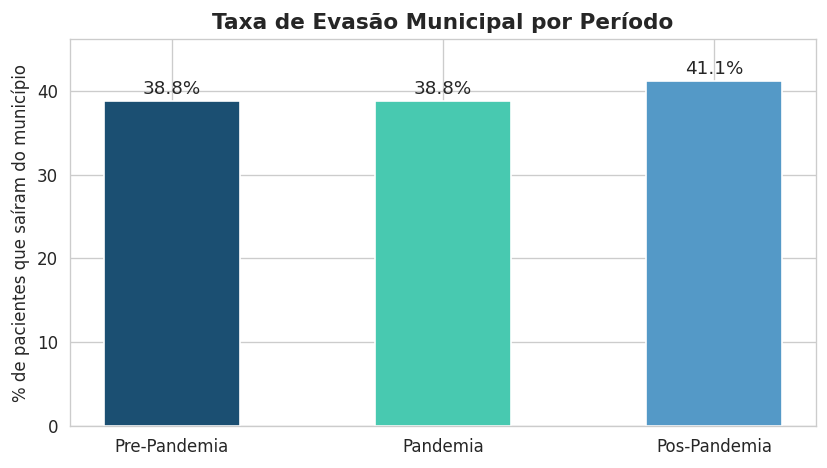

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ORDEM_PERIODOS,
    evasao_periodo['taxa_%'],
    color=[PALETTE_PERIODO[p] for p in ORDEM_PERIODOS],
    edgecolor='white', width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)
ax.set_title('Taxa de Evasão Municipal por Período', fontsize=13, fontweight='bold')
ax.set_ylabel('% de pacientes que saíram do município')
ax.set_xlabel('')
ax.set_ylim(0, evasao_periodo['taxa_%'].max() + 5)
plt.tight_layout()
plt.show()

### **3.2 Evolução Anual**

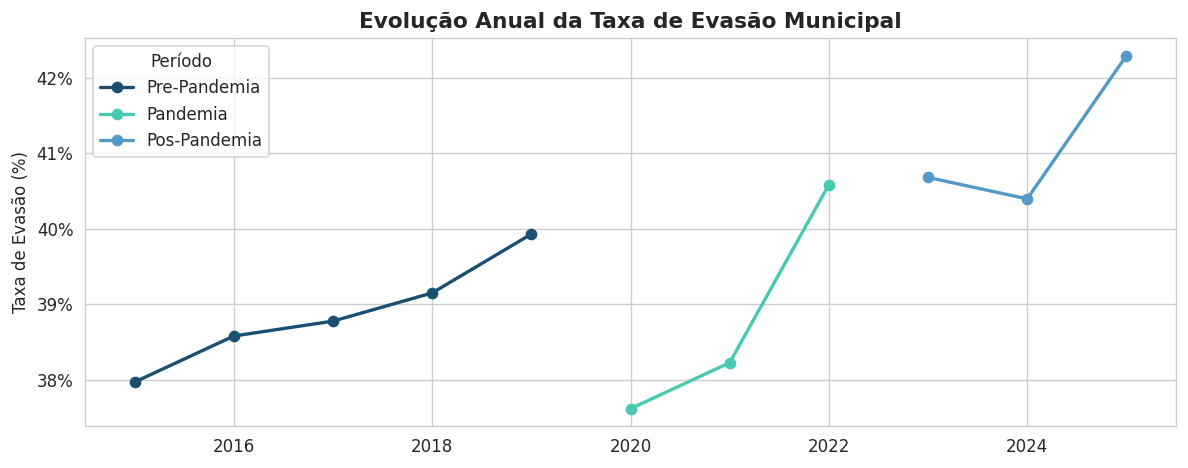

In [33]:
# Evolução anual: confirma se a evasão é estrutural ou sofreu mudança
evasao_anual = (
    df.groupby(['ANO_CMPT', 'periodo'], observed=True)['evasao_mun']
    .mean()
    .mul(100)
    .reset_index(name='taxa')
)

fig, ax = plt.subplots(figsize=(10, 4))
for periodo in ORDEM_PERIODOS:
    dados = evasao_anual[evasao_anual['periodo'] == periodo]
    ax.plot(dados['ANO_CMPT'], dados['taxa'],
            marker='o', label=periodo,
            color=PALETTE_PERIODO[periodo], linewidth=2)
ax.set_title('Evolução Anual da Taxa de Evasão Municipal', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Taxa de Evasão (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(title='Período')
plt.tight_layout()
plt.savefig(SAVEPATH + 'fig_evasao_anual.png', dpi=150, bbox_inches='tight')
plt.show()

### **3.3 Municípios com Maior Evasão (Vazios Assistenciais)**


In [34]:
# Taxa de evasão por município de residência
evasao_mun = (
    df.groupby('MUNIC_RES', observed=True)['evasao_mun']
    .agg(total='count', evasoes='sum')
)
evasao_mun['taxa_%'] = (evasao_mun['evasoes'] / evasao_mun['total'] * 100).round(1)

vazios_cronicos = evasao_mun[evasao_mun['taxa_%'] == 100].reset_index()

print(f'Total de municípios de residência: {len(evasao_mun)}')
print(f'Vazios crônicos (evasão = 100%):   {len(vazios_cronicos)}')
print(f'({len(vazios_cronicos)/len(evasao_mun)*100:.1f}% dos municípios de origem)')

Total de municípios de residência: 1256
Vazios crônicos (evasão = 100%):   925
(73.6% dos municípios de origem)


MUNIC_RES             nome_mun  taxa_%
   355640 Vargem Grande do Sul    99.9
   350030                Aguaí    99.9
   350580               Bastos    99.9
   354580 Santa Bárbara dOeste    99.9
   354020               Pontal    99.9
   353030             Mirassol    99.9
   353540             Panorama    99.9
   352570       José Bonifácio    99.8
   355600               Urupês    99.8
   355360           Tapiratiba    99.8


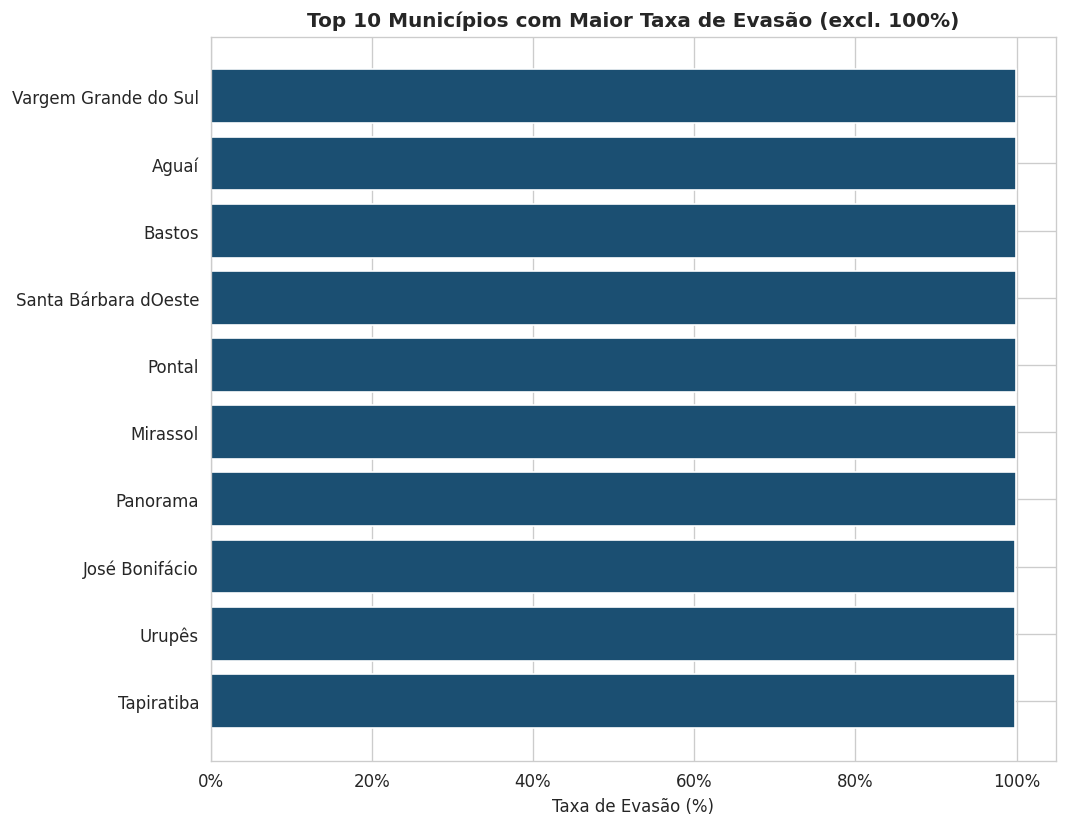

In [35]:
# Dicionário de códigos para nomes (exemplo)
MUN_LABELS = {
    '355640': 'Vargem Grande do Sul',
    '350030': 'Aguaí',
    '350580': 'Bastos',
    '354580': 'Santa Bárbara dOeste',
    '354020': 'Pontal',
    '353030': 'Mirassol',
    '353540': 'Panorama',
    '352570': 'José Bonifácio',
    '355600': 'Urupês',
    '355360': 'Tapiratiba'

}

# Criar coluna temporária só para exibir o nome, sem mexer no código original
top_evasao['nome_mun'] = top_evasao['MUNIC_RES'].map(MUN_LABELS)

# Opcional: preencher nomes vazios
top_evasao['nome_mun'] = top_evasao['nome_mun'].replace('', 'Sem nome')

# Agora você pode imprimir igual ao CID ou plotar
print(top_evasao[['MUNIC_RES', 'nome_mun', 'taxa_%']].to_string(index=False))

# E no gráfico
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    top_evasao['nome_mun'][::-1],  # só para mostrar
    top_evasao['taxa_%'][::-1],
    color=COLOR1, edgecolor='white'
)
ax.set_title('Top 10 Municípios com Maior Taxa de Evasão (excl. 100%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Taxa de Evasão (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

## **4. Análise por DRS**

### **4.1 Concentração de Internações por DRS**

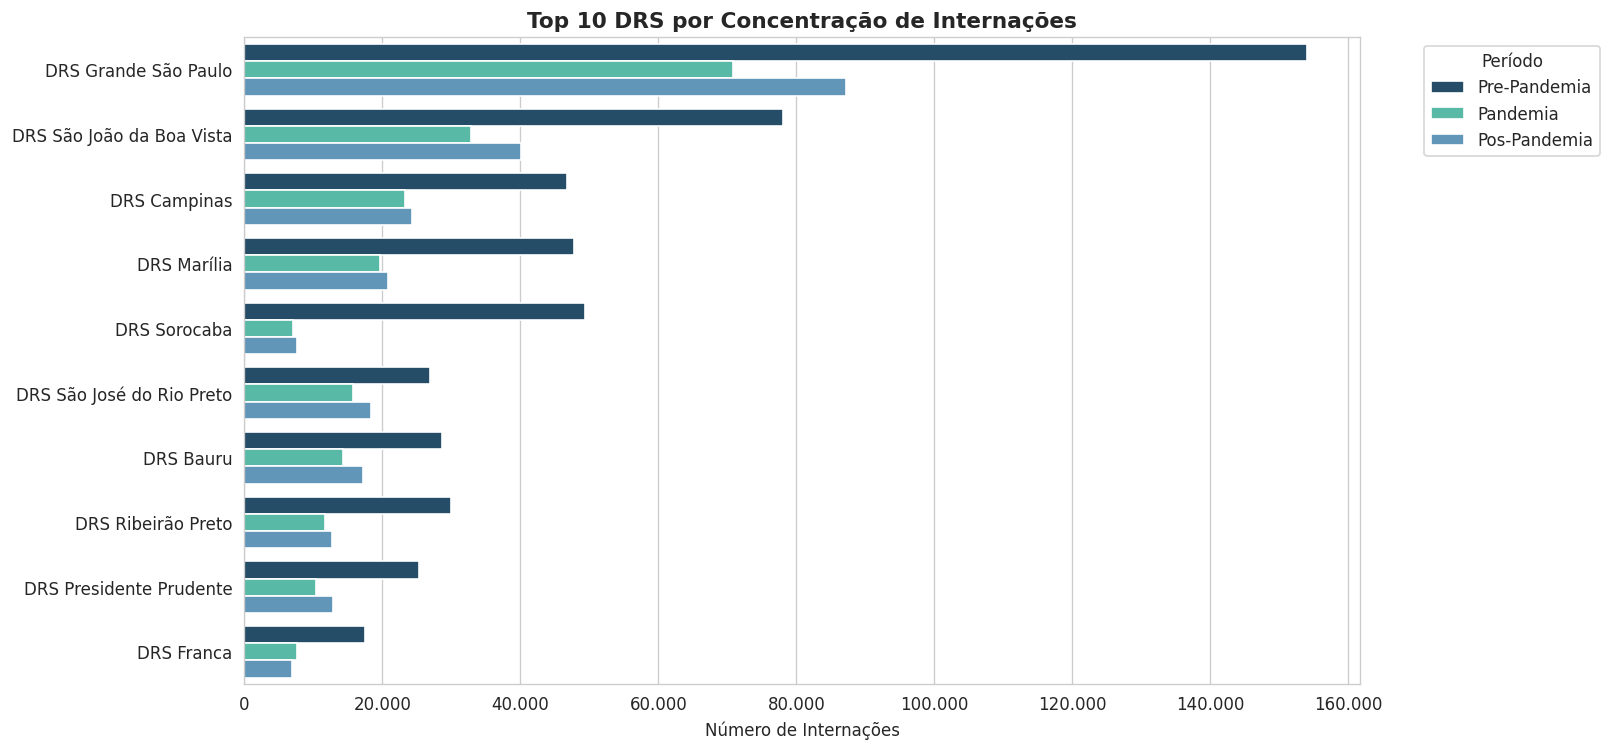

In [36]:
# criar ordem decrescente pelo total de internações
ordem_drs = (
    plot_drs.groupby('drs_internacao')['internacoes']
    .sum()
    .sort_values(ascending=False)  # maior primeiro
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_drs,
    y='drs_internacao', x='internacoes',
    hue='periodo', palette=PALETTE_PERIODO,
    order=ordem_drs,  # maior no topo
    ax=ax
)
ax.set_title('Top 10 DRS por Concentração de Internações', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Internações')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)
ax.legend(title='Período', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **4.2 Deslocamento entre DRS**

               total  deslocamentos  taxa_%
periodo                                    
Pre-Pandemia  556336          44972    8.08
Pandemia      241285          13743    5.70
Pos-Pandemia  282049          19632    6.96


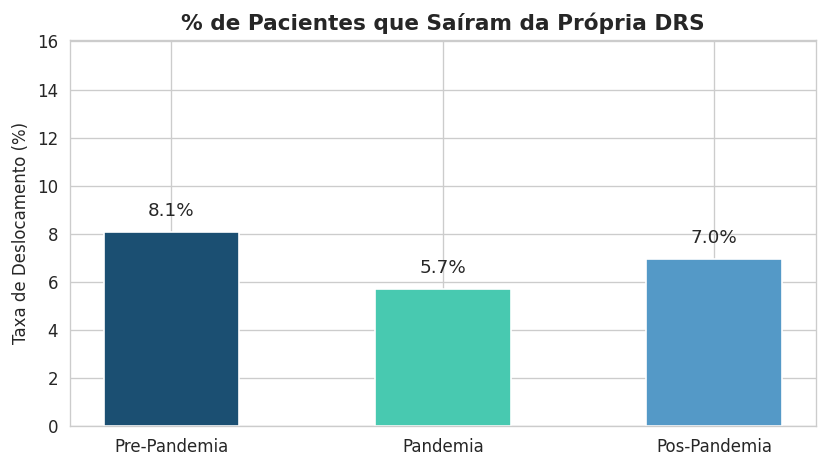

In [46]:
# Proporção de pacientes que precisaram sair da própria DRS
desloc_drs = (
    df.groupby('periodo', observed=True)['evasao_drs']
    .agg(total='count', deslocamentos='sum')
)
desloc_drs['taxa_%'] = (desloc_drs['deslocamentos'] / desloc_drs['total'] * 100).round(2)
print(desloc_drs)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ORDEM_PERIODOS, desloc_drs['taxa_%'],
    color=[PALETTE_PERIODO[p] for p in ORDEM_PERIODOS],
    edgecolor='white', width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)
ax.set_title('% de Pacientes que Saíram da Própria DRS', fontsize=13, fontweight='bold')
ax.set_ylabel('Taxa de Deslocamento (%)')
ax.set_xlabel('')
ax.set_ylim(0, desloc_drs['taxa_%'].max() + 8)
plt.tight_layout()
plt.show()

### **4.3 Ranking de Evasão por DRS**

In [38]:
# Taxa de evasão por DRS de residência
evasao_por_drs = (
    df.groupby(['periodo', 'drs_residencia'], observed=True)
    .agg(total=('evasao_drs', 'count'), evasoes=('evasao_drs', 'sum'))
    .reset_index()
)
evasao_por_drs['taxa_%'] = (evasao_por_drs['evasoes'] / evasao_por_drs['total'] * 100).round(1)

ranking_evasao = (
    evasao_por_drs
    .pivot(index='drs_residencia', columns='periodo', values='taxa_%')
    .reindex(columns=ORDEM_PERIODOS)
    .sort_values('Pre-Pandemia', ascending=False)
)

print('Ranking de evasão por DRS (%):')
ranking_evasao.round(1)

Ranking de evasão por DRS (%):


periodo,Pre-Pandemia,Pandemia,Pos-Pandemia
drs_residencia,,,
DRS Registro,72.3,49.8,33.4
DRS Baixada Santista,31.0,9.9,7.3
DRS Taubaté,30.4,29.4,31.7
DRS Barretos,23.2,6.4,3.4
DRS Araraquara,14.1,5.9,3.7
DRS Grande São Paulo,12.1,6.1,8.9
DRS Piracicaba,8.2,5.0,3.8
DRS Bauru,7.7,1.5,1.6
DRS Campinas,4.9,4.9,8.4


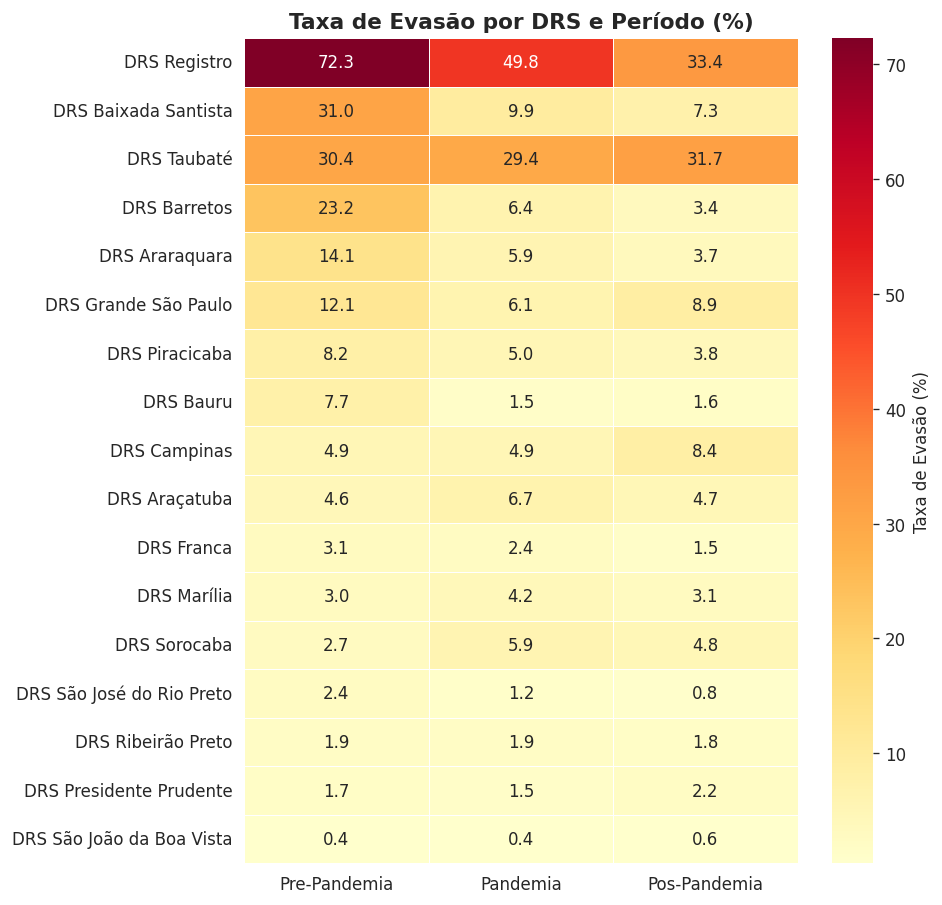

In [47]:
# Heatmap evasão por DRS x período
fig, ax = plt.subplots(figsize=(8, max(6, len(ranking_evasao) * 0.45)))
sns.heatmap(
    ranking_evasao,
    cmap='YlOrRd',
    annot=True, fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Taxa de Evasão (%)'}
)
ax.set_title('Taxa de Evasão por DRS e Período (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## **5. Fluxo Origem-Destino**

### **5.1 Principais Fluxos Municipais**

Identifica os pares origem-destino mais frequentes:
municípios que mais enviam pacientes (emissores) e os que mais recebem (polos receptores).


In [40]:
# Filtra apenas internações com evasão (origem diferente do destino)
df_evasao = df[df['evasao_mun']].copy()

# Contagem de pares OD
fluxo_od = (
    df_evasao
    .groupby(['MUNIC_RES', 'MUNIC_MOV', 'periodo'], observed=True)
    .size()
    .reset_index(name='fluxo')
    .sort_values('fluxo', ascending=False)
)

# Top 15 pares no geral
top15_od = (
    fluxo_od.groupby(['MUNIC_RES', 'MUNIC_MOV'])['fluxo']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top15_od['par_od'] = top15_od['MUNIC_RES'].astype(str) + ' -> ' + top15_od['MUNIC_MOV'].astype(str)
print('Top 15 pares origem-destino (geral):')
top15_od

Top 15 pares origem-destino (geral):


,MUNIC_RES,MUNIC_MOV,fluxo,par_od
0,355030,352260,17230,355030 -> 352260
1,353070,352260,7080,353070 -> 352260
2,350600,352530,5853,350600 -> 352530
3,353870,354390,5544,353870 -> 354390
4,354910,351518,5038,354910 -> 351518
5,353080,352260,4048,353080 -> 352260
6,353070,351518,4023,353070 -> 351518
7,354910,352260,3087,354910 -> 352260
8,351630,351640,3046,351630 -> 351640
9,350760,350190,2521,350760 -> 350190


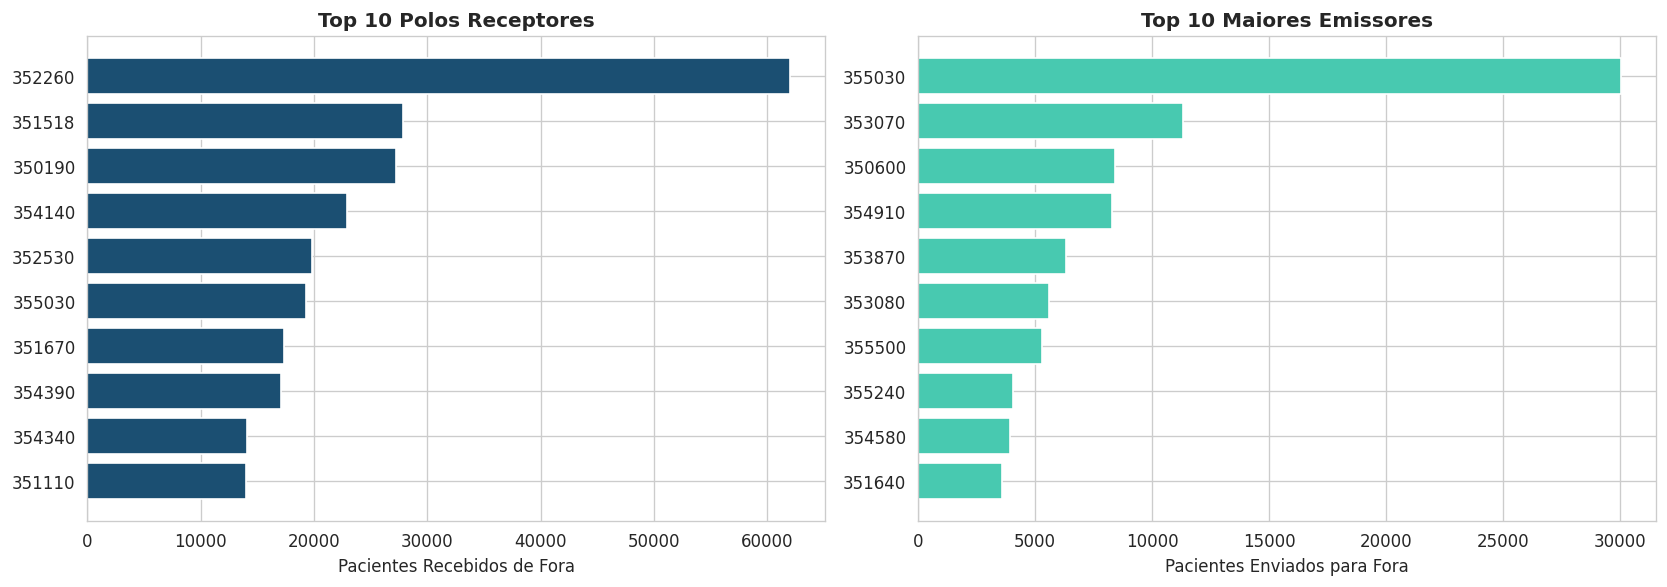

In [48]:
# Polos receptores vs. maiores emissores
polos_receptores = (
    df_evasao.groupby('MUNIC_MOV', observed=True)
    .size().sort_values(ascending=False).head(10)
    .reset_index(name='pacientes_externos')
)
maiores_evasores = (
    df_evasao.groupby('MUNIC_RES', observed=True)
    .size().sort_values(ascending=False).head(10)
    .reset_index(name='pacientes_enviados')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    polos_receptores['MUNIC_MOV'].astype(str)[::-1],
    polos_receptores['pacientes_externos'][::-1],
    color=COLOR1, edgecolor='white'
)
axes[0].set_title('Top 10 Polos Receptores', fontweight='bold')
axes[0].set_xlabel('Pacientes Recebidos de Fora')

axes[1].barh(
    maiores_evasores['MUNIC_RES'].astype(str)[::-1],
    maiores_evasores['pacientes_enviados'][::-1],
    color=COLOR2, edgecolor='white'
)
axes[1].set_title('Top 10 Maiores Emissores', fontweight='bold')
axes[1].set_xlabel('Pacientes Enviados para Fora')

plt.tight_layout()
plt.show()

### **5.2 Diagrama de Fluxo (Top Destinos por Emissor)**

In [55]:
MUN_LABELS = {
    '355030': 'São Paulo',
    '353070': 'Mogi Guaçu',
    '350600': 'Bauru',
    '354910': 'São João da Boa Vista',
    '353870': 'Piracicaba'
}

# Mapeia no df
fluxo_top5['origem_nome'] = (
    fluxo_top5['MUNIC_RES'].astype(str).map(MUN_LABELS)
    .fillna(fluxo_top5['MUNIC_RES'].astype(str))
)

fluxo_top5['destino_nome'] = (
    fluxo_top5['MUNIC_MOV'].astype(str).map(MUN_LABELS)
    .fillna(fluxo_top5['MUNIC_MOV'].astype(str))
)

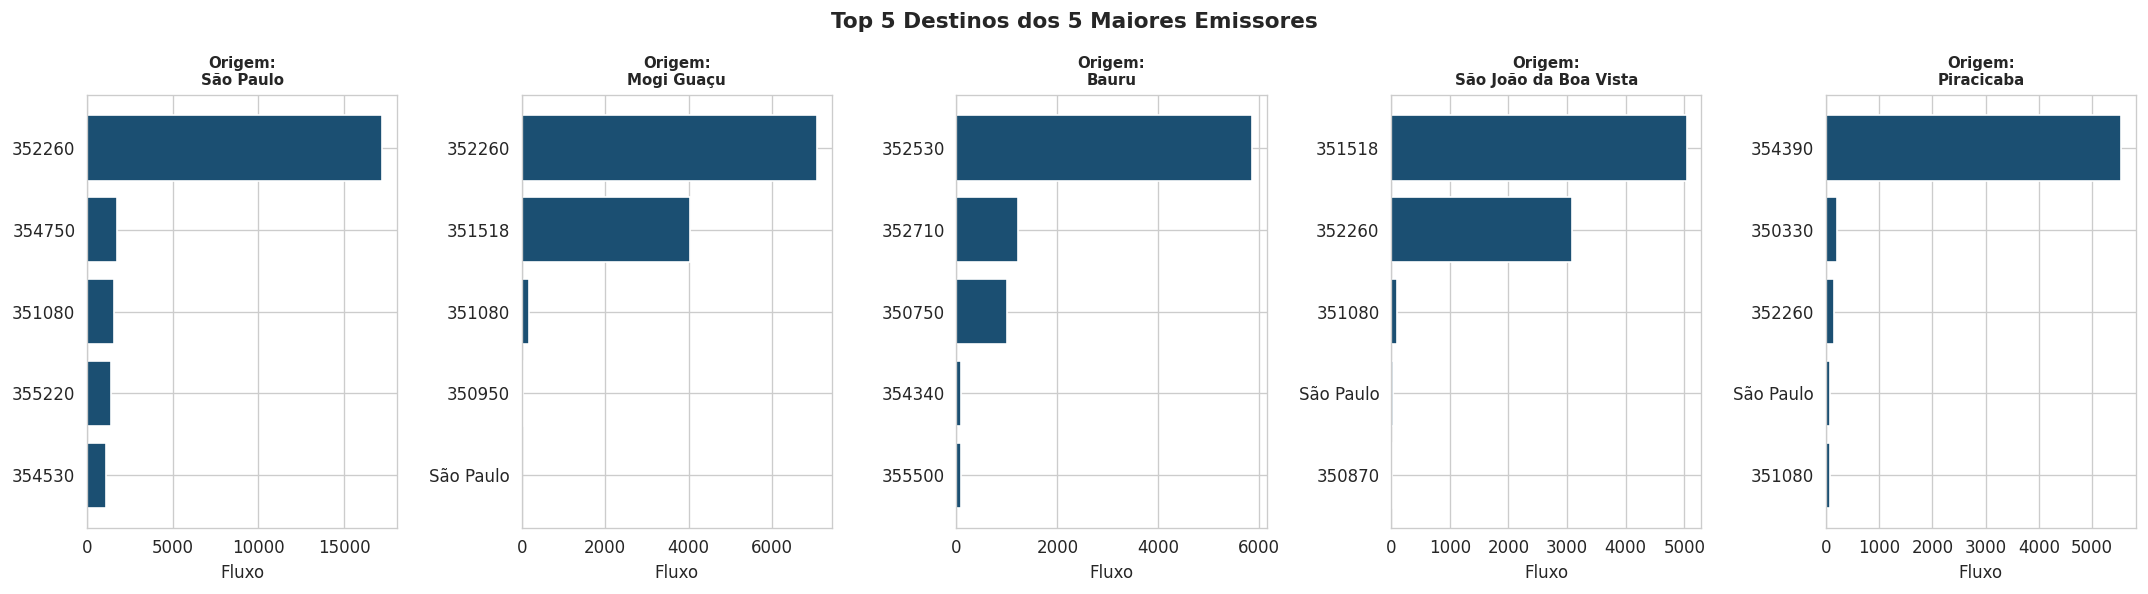

In [56]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)

for ax, mun in zip(axes, top5_emissores):
    dados = (
        fluxo_top5[fluxo_top5['MUNIC_RES'] == mun]
        .sort_values('fluxo', ascending=False)
        .head(5)
    )

    ax.barh(
        dados['destino_nome'][::-1],   # mostra nome
        dados['fluxo'][::-1],
        color=COLOR1, edgecolor='white'
    )

    origem_nome = MUN_LABELS.get(str(mun), mun)
    ax.set_title(f'Origem:\n{origem_nome}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Fluxo')

fig.suptitle('Top 5 Destinos dos 5 Maiores Emissores',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## **6. Mapas**

> Os mapas usam a geometria dos municípios de SP carregada pelo `geobr`.
> A escala de cores usa **log(internações+1)** para lidar com a forte assimetria
> causada pela dominância de São Paulo capital.


### **6.1 Concentração de Internações por Município**

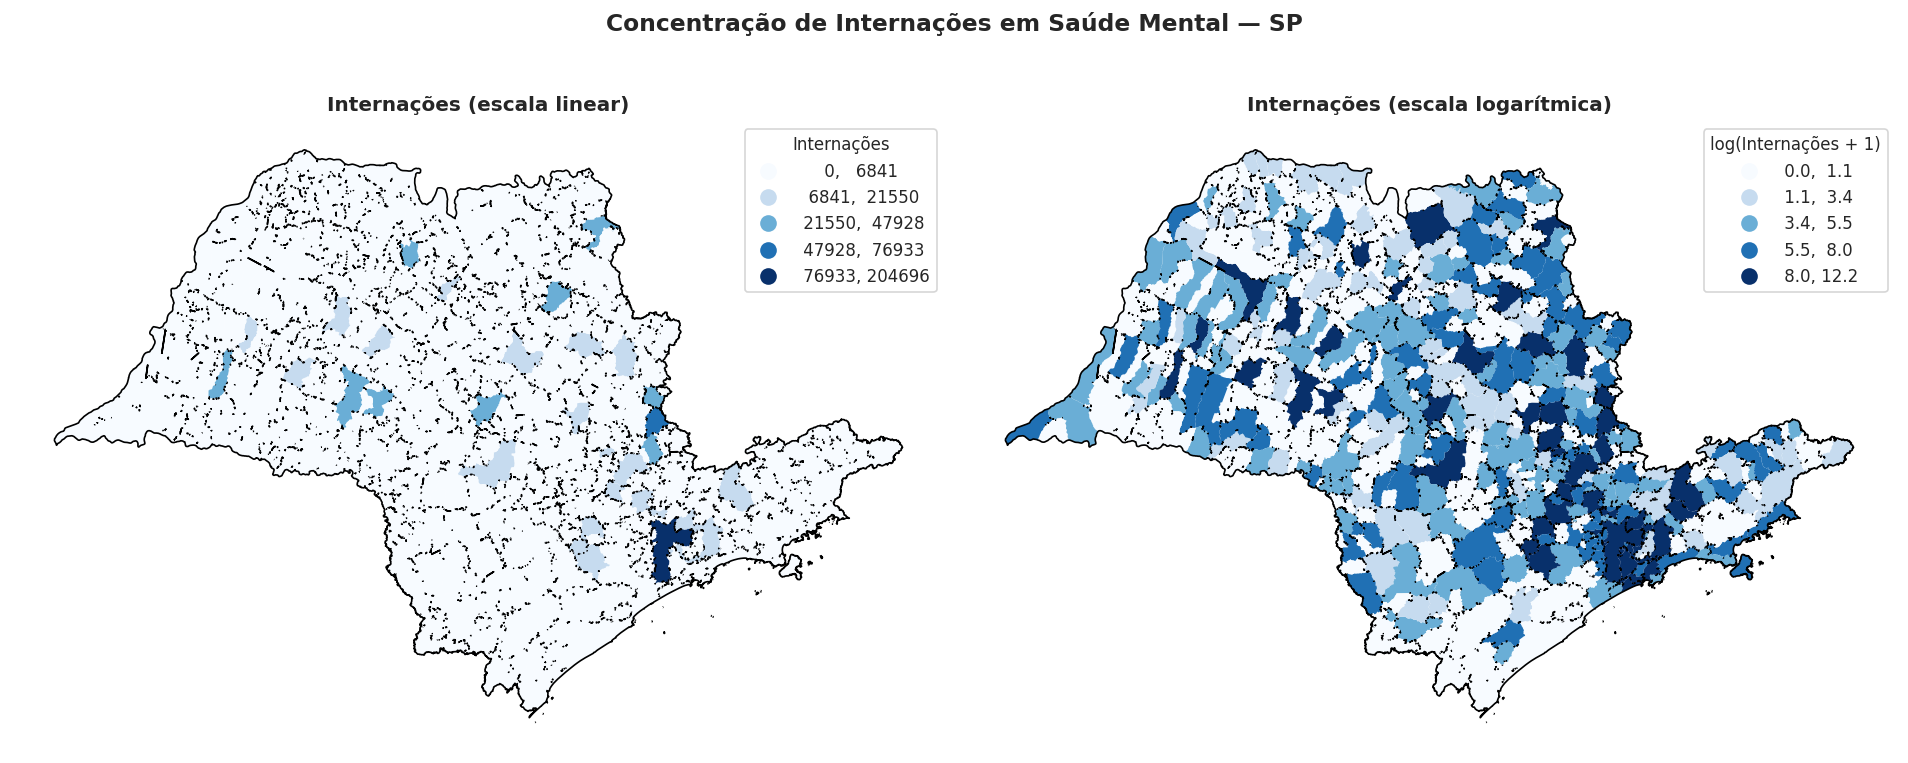

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# criar contorno único do estado
contorno_estado = municipios_sp.dissolve()

# Escala linear
mapa.plot(
    column='internacoes',
    cmap='Blues',
    scheme='naturalbreaks',
    k=5,
    legend=True,
    ax=axes[0],
    edgecolor='none',  # remove linhas dos municípios
    legend_kwds={'title': 'Internações', 'fmt': '{:.0f}'}
)

# contorno do estado
contorno_estado.boundary.plot(ax=axes[0], color='black', linewidth=1)

axes[0].set_title('Internações (escala linear)', fontweight='bold')
axes[0].axis('off')


# Escala log
mapa.plot(
    column='internacoes_log',
    cmap='Blues',
    scheme='naturalbreaks',
    k=5,
    legend=True,
    ax=axes[1],
    edgecolor='none',
    legend_kwds={'title': 'log(Internações + 1)', 'fmt': '{:.1f}'}
)

# contorno do estado
contorno_estado.boundary.plot(ax=axes[1], color='black', linewidth=1)

axes[1].set_title('Internações (escala logarítmica)', fontweight='bold')
axes[1].axis('off')

fig.suptitle(
    'Concentração de Internações em Saúde Mental — SP',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### **6.2 Taxa de Evasão por Município**

/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


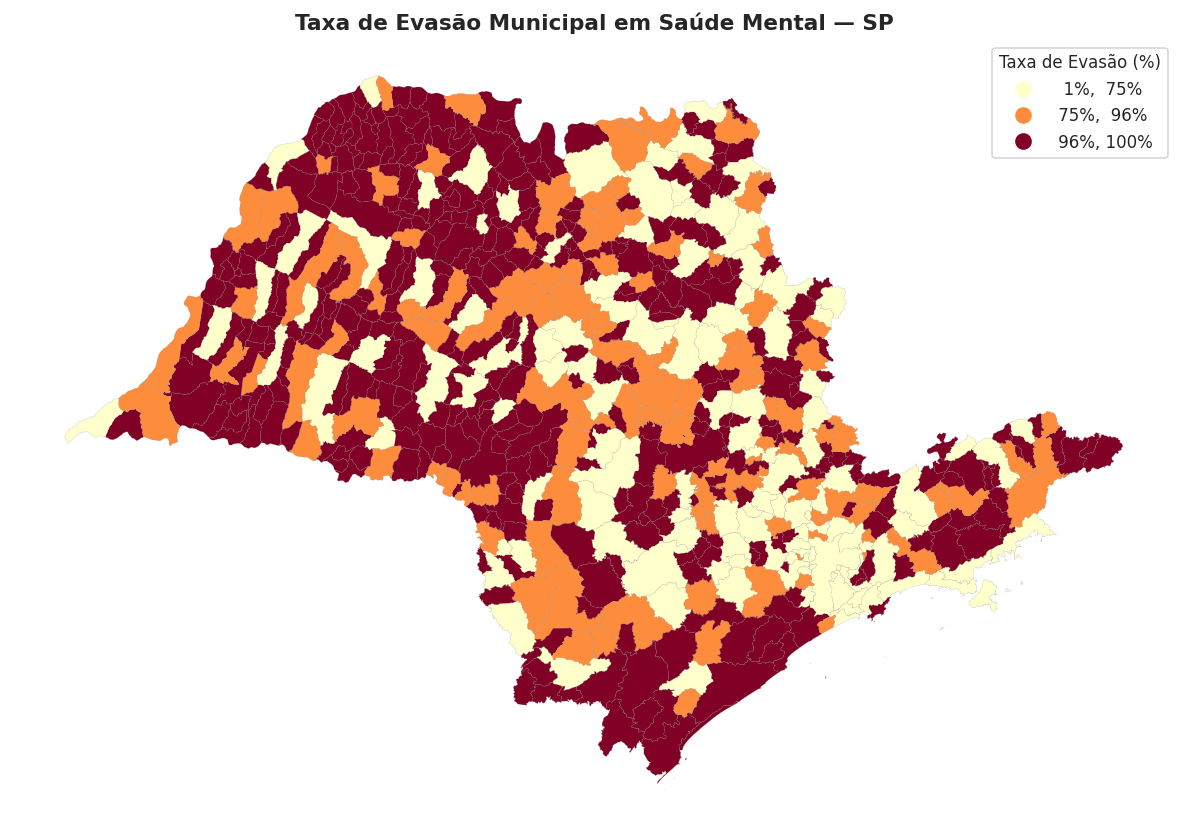

In [61]:
evasao_mun_plot = (
    df.groupby('MUNIC_RES', observed=True)['evasao_mun']
    .mean()
    .reset_index()
    .rename(columns={'MUNIC_RES': 'cod6', 'evasao_mun': 'taxa_evasao'})
)

evasao_mun_plot['taxa_evasao'] = evasao_mun_plot['taxa_evasao'] * 100

mapa_evasao = municipios_sp.merge(evasao_mun_plot, on='cod6', how='left')

fig, ax = plt.subplots(figsize=(10, 9))
mapa_evasao.plot(
    column='taxa_evasao',
    cmap='YlOrRd',
    scheme='quantiles', k=5,
    legend=True, ax=ax,
    edgecolor='grey', linewidth=0.1,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'},
    legend_kwds={'title': 'Taxa de Evasão (%)', 'fmt': '{:.0f}%'}
)
ax.set_title('Taxa de Evasão Municipal em Saúde Mental — SP',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### **6.3 Mapa Comparativo por Período**

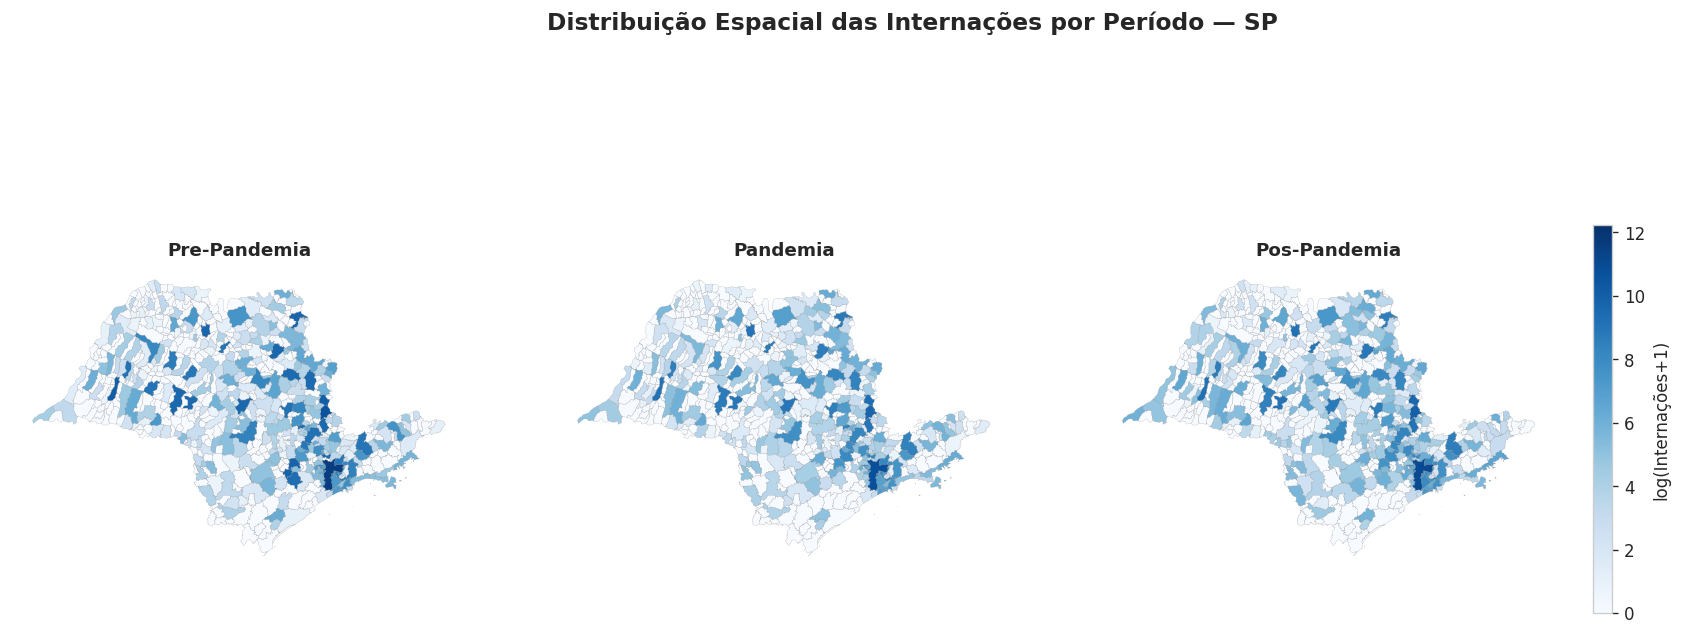

In [62]:
# Painel com 3 mapas — um por período, escala de cor compartilhada
# Permite comparar visualmente a distribuição espacial entre pré, durante e pós
vmax_log = np.log1p(df.groupby('MUNIC_MOV', observed=True).size().max())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, periodo in zip(axes, ORDEM_PERIODOS):
    int_periodo = (
        df[df['periodo'] == periodo]
        .groupby('MUNIC_MOV', observed=True)
        .size().reset_index(name='internacoes')
        .rename(columns={'MUNIC_MOV': 'cod6'})
    )
    mapa_p = municipios_sp.merge(int_periodo, on='cod6', how='left')
    mapa_p['internacoes']     = mapa_p['internacoes'].fillna(0)
    mapa_p['internacoes_log'] = np.log1p(mapa_p['internacoes'])

    mapa_p.plot(
        column='internacoes_log', cmap='Blues',
        vmin=0, vmax=vmax_log,
        ax=ax, edgecolor='grey', linewidth=0.1
    )
    ax.set_title(periodo, fontweight='bold', fontsize=11)
    ax.axis('off')

# Barra de cor compartilhada
sm = plt.cm.ScalarMappable(
    cmap='Blues',
    norm=mcolors.Normalize(vmin=0, vmax=vmax_log)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label('log(Internações+1)', fontsize=10)

fig.suptitle('Distribuição Espacial das Internações por Período — SP',
             fontsize=14, fontweight='bold')
plt.show()